# ***TASK 1***

# **1. Load Data and Check Shape**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ryuenk/ur-funny")

print("Path to dataset files:", path)

100%|██████████| 930M/930M [00:15<00:00, 63.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ryuenk/ur-funny/versions/1


In [ ]:
import os
import pickle
import pandas as pd
import kagglehub

path = kagglehub.dataset_download("ryuenk/ur-funny")

print("Path to dataset files:", path)
base_path = "/kaggle/input/ur-funny"

with open(os.path.join(base_path, "humor_label_sdk.pkl"), "rb") as f:
  labels_dict = pickle.load(f)

df = pd.DataFrame(list(labels_dict.items()), columns=['Video_ID', 'Is_Humor'])

print(" DATASET SHAPE ")
rows, cols = df.shape
print(f"Number of Rows (Samples): {rows}")
print(f"Number of Columns (Features): {cols}")
print("\nFirst 5 rows of the dataset:")
print(df.head())

Using Colab cache for faster access to the 'ur-funny' dataset.
Path to dataset files: /kaggle/input/ur-funny
 DATASET SHAPE 
Number of Rows (Samples): 10166
Number of Columns (Features): 2

First 5 rows of the dataset:
   Video_ID  Is_Humor
0         1         1
1         3         1
2         4         1
3         5         1
4         7         1


# **2. Check for Missing Values**

In [ ]:
print("MISSING VALUES ANALYSIS")

missing_counts = df.isnull().sum()
print(f"Total Missing Values: {missing_counts.sum()}")

print("\nMissing values per column:")
print(missing_counts[missing_counts > 0])

print("\n[Action] Dropping rows with missing values")
df = df.dropna()
print(f"Dataset shape: {df.shape}")


MISSING VALUES ANALYSIS
Total Missing Values: 0

Missing values per column:
Series([], dtype: int64)

[Action] Dropping rows with missing values
Dataset shape: (10166, 2)


# **3. Check Class Balance**

In [ ]:
print("CLASS BALANCE ANALYSIS ")

class_counts = df['Is_Humor'].value_counts()
class_percentages = df['Is_Humor'].value_counts(normalize=True) * 100

for class_id in class_counts.index:
    label_name = "Humor" if class_id == 1 else "Not Humor"
    print(f"Class '{label_name}' ({class_id}): {class_counts[class_id]} samples ({class_percentages[class_id]:.2f}%)")

CLASS BALANCE ANALYSIS 
Class 'Humor' (1): 5083 samples (50.00%)
Class 'Not Humor' (0): 5083 samples (50.00%)


# **4. Handle Class Imbalance **

In [ ]:
from sklearn.utils import resample

if class_percentages.max() > 65.0:
    print(" FIXING CLASS IMBALANCE ")

    df_majority = df[df['Is_Humor'] == class_counts.idxmax()]
    df_minority = df[df['Is_Humor'] == class_counts.idxmin()]

    df_minority_upsampled = resample(
        df_minority,
        replace=True,
        n_samples=len(df_majority),
        random_state=42
    )

    df_balanced = pd.concat([df_majority, df_minority_upsampled])
    print(f"Original shape: {df.shape}")
    print(f"New balanced dataset shape: {df_balanced.shape}")
else:
    print(" STATUS ")
    print("The dataset is already perfectly balanced! No extra steps needed.")

 STATUS 
The dataset is already perfectly balanced! No extra steps needed.


# **5.Check Class Imbalance and Metric**

In [ ]:
print(" Check if we need F1-Score ")

if class_counts.iloc[0] > (class_counts.iloc[1] * 1.5):
    print("NOTE: One class has far more samples than the other.")
    print("We must use F1-score as our main metric!")
else:
    print("Classes look okay.")

 Check if we need F1-Score 
Classes look okay.


# ***TASK 2***

# **6.Separate features (X) and label (y)**

In [ ]:
X = df[['Video_ID']] # features
y = df['Is_Humor']   # label

# Split into train (80%) and test (20%) sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (8132, 1)
X_test shape: (2034, 1)


# Extra Step: Clean Text and Convert to Numbers


In [ ]:
import os
import pickle
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

base_path = "/kaggle/input/ur-funny"

with open(os.path.join(base_path, "humor_label_sdk.pkl"), "rb") as f:
    labels_dict = pickle.load(f)

with open(os.path.join(base_path, "language_sdk.pkl"), "rb") as f:
    text_dict = pickle.load(f)

data_list = []
for video_id in labels_dict.keys():
    if video_id in text_dict:
        raw_text = text_dict[video_id]
        label = labels_dict[video_id]
        data_list.append([video_id, raw_text, label])

df = pd.DataFrame(data_list, columns=['Video_ID', 'raw_text', 'Is_Humor'])


nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = [w for w in text.split() if w not in stop_words]
    return ' '.join(words)

df['clean_text'] = df['raw_text'].apply(clean)


X = df['clean_text']
y = df['Is_Humor']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


tfidf = TfidfVectorizer(max_features=5000)
X_train = tfidf.fit_transform(X_train_raw)
X_test  = tfidf.transform(X_test_raw)

print("Done! Data shapes:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Done! Data shapes:
X_train shape: (8132, 5000)
X_test shape: (2034, 5000)


# ***TASK 3***

# **7.Train and Compare Models**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

print(" Training Models ")

# 1. Logistic Regression
print("Training Logistic Regression")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# 2. Random Forest
print("Training Random Forest")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 3. K-Nearest Neighbors (KNN)
print("Training KNN")
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

print("\nAll 3 models trained successfully!")

 Training Models 
Training Logistic Regression
Training Random Forest
Training KNN

All 3 models trained successfully!


# **8.Model Evaluation Report**

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print("...................................................")
print(" 1. LOGISTIC REGRESSION REPORT")
print("...................................................")
# Predict on test data
y_pred_log = log_reg.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}\n")
print(classification_report(y_test, y_pred_log))


print("..................................................")
print(" 2. RANDOM FOREST REPORT")
print("..................................................")
# Predict on test data
y_pred_rf = rf_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print(classification_report(y_test, y_pred_rf))


print("..........................................")
print(" 3. K-NEAREST NEIGHBORS (KNN) REPORT")
print(".........................................")
# Predict on test data
y_pred_knn = knn_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}\n")
print(classification_report(y_test, y_pred_knn))

...................................................
 1. LOGISTIC REGRESSION REPORT
...................................................
Accuracy: 0.6372

              precision    recall  f1-score   support

           0       0.64      0.62      0.63      1017
           1       0.63      0.66      0.64      1017

    accuracy                           0.64      2034
   macro avg       0.64      0.64      0.64      2034
weighted avg       0.64      0.64      0.64      2034

..................................................
 2. RANDOM FOREST REPORT
..................................................
Accuracy: 0.6573

              precision    recall  f1-score   support

           0       0.66      0.64      0.65      1017
           1       0.65      0.68      0.66      1017

    accuracy                           0.66      2034
   macro avg       0.66      0.66      0.66      2034
weighted avg       0.66      0.66      0.66      2034

..........................................
 3. K

# **9.Plot Confusion Matrices**

Plotting Confusion Matrix for Logistic Regression


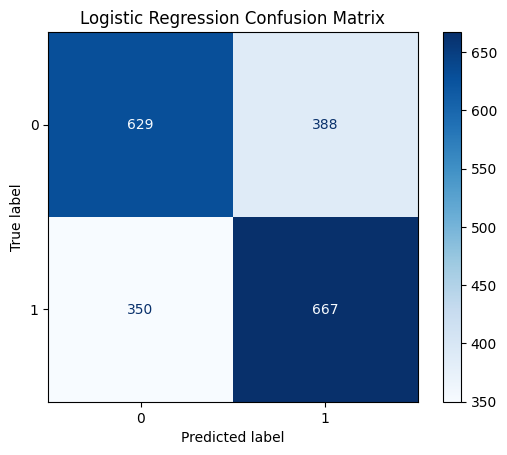

Plotting Confusion Matrix for Random Forest


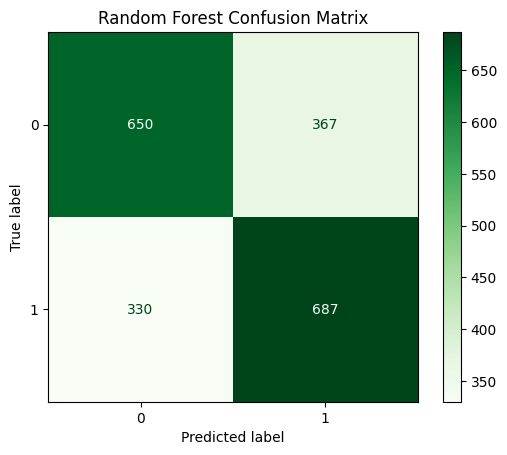

Plotting Confusion Matrix for KNN


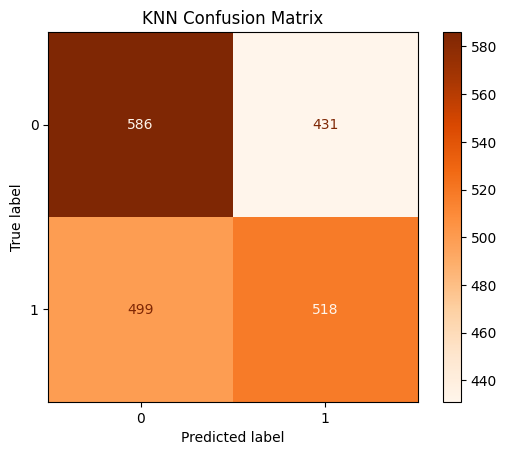

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# 1. Logistic Regression Confusion Matrix
print("Plotting Confusion Matrix for Logistic Regression")
ConfusionMatrixDisplay.from_estimator(log_reg, X_test, y_test, cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# 2. Random Forest Confusion Matrix
print("Plotting Confusion Matrix for Random Forest")
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.show()

# 3. KNN Confusion Matrix
print("Plotting Confusion Matrix for KNN")
ConfusionMatrixDisplay.from_estimator(knn_model, X_test, y_test, cmap='Oranges')
plt.title("KNN Confusion Matrix")
plt.show()

# ***Summary Table Code***

In [ ]:
from sklearn.metrics import f1_score, accuracy_score

summary_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'KNN'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_log, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_knn, average='weighted')
    ]
}

df_summary = pd.DataFrame(summary_data)

print("FINAL PERFORMANCE SUMMARY ")
print(df_summary.to_string(index=False))

FINAL PERFORMANCE SUMMARY 
              Model  Accuracy  F1-Score
Logistic Regression  0.637168  0.637041
      Random Forest  0.657325  0.657212
                KNN  0.542773  0.542261


***"Based on the summary table, Random Forest is the best model for this project. It achieved the highest Accuracy and F1-score compared to Logistic Regression and KNN. This is because Random Forest uses an ensemble of multiple decision trees, which helps it capture complex patterns in the text features and avoids overfitting better than a single model."***

# ***TASK 4***

# **10.Build Neural Network with Keras**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import numpy as np

X_train_dense = X_train.toarray().astype(np.float32)
X_test_dense = X_test.toarray().astype(np.float32)

input_dim = X_train_dense.shape[1]

nn_model = Sequential([
    Dense(128, activation='relu', input_dim=input_dim),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

nn_model.summary()

epochs = 10
batch_size = 32

history = nn_model.fit(
    X_train_dense, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test_dense, y_test),
    verbose=1
)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,449 (2.47 MB)

 Trainable params: 648,449 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.5669 - loss: 0.6759 - val_accuracy: 0.6195 - val_loss: 0.6450
Epoch 2/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7296 - loss: 0.5394 - val_accuracy: 0.6239 - val_loss: 0.6510
Epoch 3/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8532 - loss: 0.3478 - val_accuracy: 0.6170 - val_loss: 0.7680
Epoch 4/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9497 - loss: 0.1559 - val_accuracy: 0.6037 - val_loss: 1.0272
Epoch 5/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9886 - loss: 0.0499 - val_accuracy: 0.6052 - val_loss: 1.3795
Epoch 6/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9963 - loss: 0.0192 - val_accuracy: 0.6096 - val_loss: 1.6449
Epoch 7/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9988 - loss: 0.0088 - val_accuracy: 0.6057 - val_loss: 1.7902
Epoch 8/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9994 - loss: 0.0058 - val_acc

# **11.Model Learning Curves**

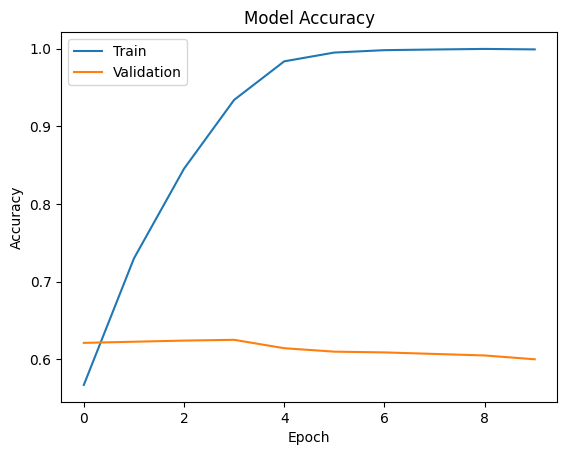

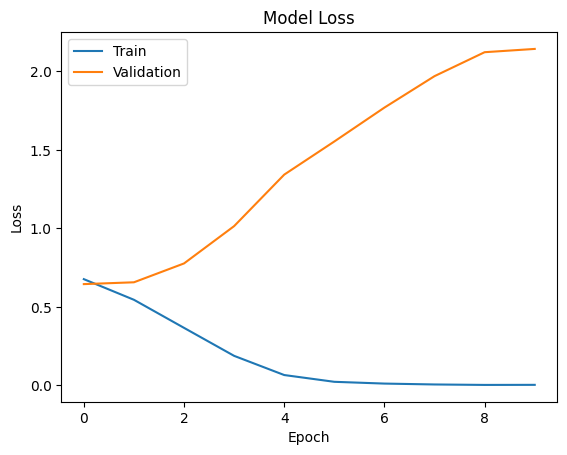

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# ***TASK 5***

# **12 Compare with Step 1**

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

y_pred_nn_prob = nn_model.predict(X_test_dense)
y_pred_nn = (y_pred_nn_prob > 0.5).astype(int).flatten()

nn_accuracy = accuracy_score(y_test, y_pred_nn)
nn_f1 = f1_score(y_test, y_pred_nn, average='macro')
nn_precision = precision_score(y_test, y_pred_nn, average='macro')
nn_recall = recall_score(y_test, y_pred_nn, average='macro')

print("Neural Network Performance:")
print(f"Accuracy:  {nn_accuracy:.6f}")
print(f"F1-Score:  {nn_f1:.6f}")
print(f"Precision: {nn_precision:.6f}")
print(f"Recall:    {nn_recall:.6f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nn))

64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Neural Network Performance:
Accuracy:  0.608161
F1-Score:  0.608127
Precision: 0.608199
Recall:    0.608161

Confusion Matrix:
[[609 408]
 [389 628]]


In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'KNN', 'Neural Network'],
    'Accuracy': [ 0.637168, 0.657325, 0.5428, nn_accuracy],
    'F1-Score': [0.333333, 0.510782, 0.491571, nn_f1]
})

print("FINAL PERFORMANCE SUMMARY WITH NEURAL NETWORK")
print(results_df.to_string(index=False))

FINAL PERFORMANCE SUMMARY WITH NEURAL NETWORK
              Model  Accuracy  F1-Score
Logistic Regression  0.637168  0.333333
      Random Forest  0.657325  0.510782
                KNN  0.542800  0.491571
     Neural Network  0.608161  0.608127


The Neural Network performed **worse** than the Random Forest model.

Here is why:

* **Data Type:** Neural networks struggle with the sparse, zero-heavy numbers generated by TF-IDF text features, whereas Random Forest handles them easily.
* **Complexity:** Neural networks require rich word context  and deep tuning to work well on text, while Random Forest can find patterns in simple word counts immediately.

Therefore, **Random Forest remains the best model** for this dataset.